In [ ]:
!pip -q install medmnist torch torchvision scikit-learn

In [ ]:
import random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import roc_auc_score
import medmnist
from medmnist import INFO
from tqdm import tqdm

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
#DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED)


In [ ]:
data_flag = "dermamnist"
info = INFO[data_flag]
print(info)
DataClass = getattr(medmnist, info["python_class"]) #medmnist modülünün içinde adı “DermaMNIST” olan sınıfı bul ve bana ver demektir.
print(DataClass)
print("Labels:", info["label"])

{'python_class': 'DermaMNIST', 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.', 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1', 'MD5': '0744692d530f8e62ec473284d019b0c7', 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1', 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f', 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1', 'MD5_128': '2defd784463fa5243564e855ed717de1', 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1', 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d', 'task': 'multi-class', 'la

In [ ]:
# ResNet için 224x224 + ImageNet normalize
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224)),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_ds = DataClass(split="train", transform=tfm, download=True)
val_ds   = DataClass(split="val", transform=tfm, download=True)
test_ds  = DataClass(split="test", transform=tfm, download=True)

In [ ]:
train_ds,val_ds,test_ds

(Dataset DermaMNIST of size 28 (dermamnist)
     Number of datapoints: 7007
     Root location: /Users/arisoy/.medmnist
     Split: train
     Task: multi-class
     Number of channels: 3
     Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
     Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
     Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
     License: CC BY-NC 4.0,
 Dataset DermaMNIST of size 28 (dermamnist)
     Numb

In [ ]:
train_ds.labels,train_ds.labels.shape

(array([[0],
        [5],
        [5],
        ...,
        [2],
        [5],
        [5]], dtype=uint8),
 (7007, 1))

In [31]:
def get_labels(ds):
    return ds.labels.squeeze().astype(int) #squeeze Boyutu 1 olan eksenleri kaldırır. mesela (7007, 1) → (7007,) yapar.
    #astype(int):Etiketleri tamsayı tipe çevirir.

train_y = get_labels(train_ds)
test_y  = get_labels(test_ds)
num_classes = len(info["label"])
print("Num classes:", num_classes)

Num classes: 7


In [40]:
test_y

array([5, 3, 4, ..., 5, 5, 5])

In [32]:
# Encoder: Pretrained ResNet18 -> embedding

class Encoder(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        base = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # avgpool sonrası yani burada ResNet18’in “son sınıflandırma katmanını” atıp, sadece özellik çıkarıcı (feature extractor) kısmını almak istedik yani head i attık sadece baştaki özellik çıkarma kısmını aldık
        #[:-1] base modelin tüm katmanlarındaki  son katman olan sınıflandırma katmanını (fc) çıkarır:
        self.proj = nn.Linear(512, emb_dim)

    def forward(self, x):
        #self.backbone(x) böyle bir çıktı verir ->[B, 512, 1, 1]
        z = self.backbone(x).squeeze(-1).squeeze(-1)  # [B,512] [B, 512, 1, 1] → [B, 512] Yani artık her görüntü için 512 boyutlu bir embedding/özellik vektörü elde ediyorsunuz.
        z = self.proj(z)                               # [B,emb] B: batch size demek
        z = F.normalize(z, dim=-1)                    # dim=-1 demek: son boyut boyunca normalize et demek. cosine uyumlu
        
        # F.normalize’a giren: [B, emb_dim] (ör. [16, 256])

        # dim=-1 demek: son boyut boyunca normalize et demek.

        # Yani her örneğin 256 boyutlu vektörünü alır,

        # onun L2 normunu 1 yapar.normalize sonrası ~1.0 görürsünüz
        return z

encoder = Encoder(emb_dim=256).to(DEVICE)

#Backbone sabit kalır (ImageNet’te öğrendiklerini korur), Sadece eklediğiniz proj/başlık katmanı (ör. self.proj) öğrenir.
for p in encoder.backbone.parameters():
    p.requires_grad = False


In [36]:
opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, encoder.parameters()), lr=2e-3) #encoder içindeki “eğitilebilir” (frozen olmayan) parametreleri alıp, onları güncelleyecek bir AdamW optimizer oluşturur

# filter(...) şunu yapar:
# Sadece requires_grad=True olan parametreleri seç.
# Yani optimizer backbone’u değil, genelde sadece proj katmanını günceller.

In [ ]:
# Episode sampling (ProtoNet)

# Episode (mini görev) üretir.
# ds: dataset (train_ds gibi)
# labels_np: etiketlerin numpy dizisi (ör. shape (N,))
# class_pool: hangi sınıflardan seçim yapılacak (base sınıflar)
# n_way: episode içinde kaç sınıf olacak? (örn 5-way)
# k_shot: her sınıftan kaç “destek” örnek? (örn 5-shot)
# q_query: her sınıftan kaç “sorgu/test” örnek? (örn 10)

def sample_episode(ds, labels_np, class_pool, n_way=5, k_shot=5, q_query=10):
    chosen = random.sample(class_pool, n_way) #class_pool içinden rastgele n_way tane sınıf seçer.
    support_idx, query_idx = [], [] #destek ve sorgu örneklerinin indekslerini tutacak listeler
    for c in chosen: #Seçilen her sınıf için tek tek support ve query örnekleri toplanır
        idxs = np.where(labels_np == c)[0].tolist() #Dataset içindeki etiketlerde c olan örneklerin tüm indekslerini bulur.np.where(...) sonuç verir, [0] ile indeks dizisi alınır.tolist() Python listesine çevirir.Örn: sınıf 2’nin dataset içindeki tüm örnek indeksleri.
        random.shuffle(idxs) #Bulunan indeksleri karıştırır ki her episode farklı örnekler seçilsin.
        support_idx += idxs[:k_shot] #Karıştırılmış listeden ilk k_shot tanesini support’a ekler.
        query_idx   += idxs[k_shot:k_shot+q_query] #Aynı sınıftan support’ta kullanılanlardan sonrakileri query set olarak alır.

    #Verilen indeks listesini alıp batch tensor haline getiren yardımcı fonksiyon.
    def load(indices):
        xs, ys = [], [] #Görüntüler xs, etiketler ys listelerinde biriktirilecek.
        for i in indices:
            x, y = ds[i]
            xs.append(x)
            ys.append(int(y))
        return torch.stack(xs).to(DEVICE), torch.tensor(ys).to(DEVICE) #torch.stack(xs) → listeyi tek tensöre çevirir.Örn: xs 25 görüntüyse → [25, 3, 224, 224]

    sx, sy = load(support_idx)
    qx, qy = load(query_idx)
    return sx, sy, qx, qy

# emb_s: support embeddingleri → [S, D] (S= support sayısı, D=embedding boyutu)
# y_s: support etiketleri → [S]
# emb_q: query embeddingleri → [Q, D]
# Bu fonksiyon:
# Her sınıf için prototip hesaplar (support embedding ortalaması)
# Query embeddinglerin prototiplere benzerliğini hesaplar (logits)
def proto_logits(emb_q, emb_s, y_s):
    classes = torch.unique(y_s) #Support içindeki benzersiz sınıfları bulur.
    protos = torch.stack([emb_s[y_s==c].mean(0) for c in classes])  # [C,D] #emb_s[y_s==c] → support embeddinglerinden etiketi c olanları seçer.
                                                                    #o sınıfın embedding ortalaması alınır → [D] bu vektöre prototip denir.
                                                                    #Bunu her sınıf için yapar ve torch.stack ile birleştirir: protos boyutu: [C, D]
    
    logits = emb_q @ protos.T  # cosine similarity. yani Her query için her prototiple benzerlik skoru çıkar:
    #emb_q: [Q, D]
    #protos.T: [D, C] C = n_way
    #Matris çarpımı sonucu:logits: [Q, C]
    return logits, classes, protos

    # logits: [Q, C] (sınıf skorları)
    # classes: prototiplerin hangi gerçek sınıflara ait olduğunu gösterir
    # protos: prototip vektörleri [C, D]


In [ ]:
#META-TRAIN (base classes) - episodic training

# "nadir hastalık" gibi davranacağımız novel sınıfı seçelim:
NOVEL_CLASS = 0
BASE_CLASSES = [c for c in range(num_classes) if c != NOVEL_CLASS]

def meta_train(episodes=400, n_way=5, k_shot=5, q_query=10):
    encoder.train() #Modeli train moduna alır. Dropout/BatchNorm gibi katmanlar varsa eğitim davranışına geçer.(Biz backbone’u dondursak bile proj katmanı train olur.)
    pbar = tqdm(range(1, episodes+1))
    for ep in pbar:
        sx, sy, qx, qy = sample_episode(train_ds, train_y, BASE_CLASSES, n_way, k_shot, q_query)
        emb_s = encoder(sx) #Çıktı: support embedding → [S, D] S = n_way*k_shot D = emb_dim (ör. 256)
        emb_q = encoder(qx) #Query görüntülerini encoder’dan geçirir. Çıktı: query embedding → [Q, D] Q = n_way*q_query

        logits, ep_classes, _ = proto_logits(emb_q, emb_s, sy) #Support embeddinglerinden sınıf başına prototip çıkarır (ortalama).Her query embedding’in her prototipe yani her sınıfa benzerliğini hesaplar.
        #ep_classes: o episode’da seçilmiş gerçek sınıf id’leri (örn [2,5,6,1,3])
        
        # qy'yi episode class indekslerine map et
        c2i = {int(c): i for i,c in enumerate(ep_classes)} #gerçek sınıf id’sini (dataset içindeki) episode içi indekse çevirir. Örn: {2:0,5:1,6:2,1:3,3:4}
        qy_map = torch.tensor([c2i[int(y)] for y in qy], device=DEVICE) #qy içindeki gerçek etiketleri, episode içi indekslere çevirir. Örn: qy içindeki 5 etiket varsa ve episode sınıfları [2,5,6,1,3] ise → [0,1,2,3,4] yapar.

        loss = F.cross_entropy(logits, qy_map)
        # logits: modelin tahmin skorları [Q, C]
        # qy_map: doğru sınıf indeksleri [Q]
        # Amaç: query örnekleri doğru prototipe yakın olsun.

        opt.zero_grad()
        loss.backward()
        opt.step()

        if ep % 50 == 0:
            acc = (logits.argmax(1) == qy_map).float().mean().item() #logits.argmax(1) → her query için en yüksek skorlu sınıf index’i (0..C-1) 
                                                                #.item() → Python sayısına çevirir
            pbar.set_description(f"ep={ep} loss={loss.item():.3f} acc={acc:.3f}") 

meta_train(episodes=400)

  0%|          | 0/400 [00:00<?, ?it/s]/var/folders/97/hx1gdk894ld8_ffpqcx13mx00000gn/T/ipykernel_4140/891892290.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ys.append(int(y))
ep=400 loss=1.168 acc=0.560: 100%|██████████| 400/400 [01:17<00:00,  5.16it/s]


In [ ]:
#sx, sy, qx, qy = sample_episode(train_ds, train_y, BASE_CLASSES, n_way, k_shot, q_query) açıklaması

# train_ds: eğitim dataseti

# train_y: etiketler

# BASE_CLASSES: “novel sınıf hariç” sınıflar (meta-train için)

# Çıktılar:

# sx = support görüntüleri (tensor) → shape: [n_way*k_shot, 3, H, W]

# sy = support etiketleri → [n_way*k_shot]

# qx = query görüntüleri → [n_way*q_query, 3, H, W]

# qy = query etiketleri → [n_way*q_query]

In [60]:
#5-SHOT NOVEL TEST: "novel vs other" + AUC + threshold

@torch.no_grad() #yani Bu fonksiyon çalışırken gradyan hesaplanmaz.çünkü eğitim yapılmıyor sadece değerlendirme yapılıyor.
#novel sınıftan support olarak kaç örnek alınacak (5-shot)
#query/test için novel’den 200, other’dan 200 örnek alınacak. Çünkü burada yaptığımız şey “novel hastalığı var mı / yok mu?”
# diye ikili (binary) bir karar vermek: novel vs other. Bunun için testte hem pozitif (novel) hem de negatif (other) örnek görmek zorundayız.

def fewshot_novel_eval(k_shot=5, q=10):
    encoder.eval()

    novel_idxs = np.where(test_y == NOVEL_CLASS)[0].tolist() #test_y içinden etiketi NOVEL_CLASS olan örneklerin indekslerini bulur.Bunlar “nadir hastalık” kabul edilen sınıfın test örnekleri.
    print("Novel idxs:", novel_idxs)
    other_idxs = np.where(test_y != NOVEL_CLASS)[0].tolist() #NOVEL_CLASS olmayan tüm diğer sınıfların indekslerini bulur.
    print("Other idxs:", other_idxs)
    random.shuffle(novel_idxs); random.shuffle(other_idxs)

    support_novel = novel_idxs[:k_shot] #Novel sınıftan ilk k_shot tane örneği support’a alır.
    support_other = other_idxs[:k_shot]  # "diğer" için de küçük destek Other tarafı için de k_shot tane örnek alır.
    support_idx = support_novel + support_other

    query_novel = novel_idxs[k_shot:k_shot+q]
    query_other = other_idxs[k_shot:k_shot+q]
    query_idx = query_novel + query_other

    def load_bin(indices):
        xs, ys = [], []
        for i in indices:
            x, _ = test_ds[i]
            xs.append(x)
            ys.append(1 if test_y[i]==NOVEL_CLASS else 0)
        return torch.stack(xs).to(DEVICE), torch.tensor(ys).to(DEVICE)

    sx, sy = load_bin(support_idx)
    qx, qy = load_bin(query_idx)

    emb_s = encoder(sx)
    emb_q = encoder(qx)

    proto_other = emb_s[sy==0].mean(0, keepdim=True) #Support embeddinglerinden sy==0 (other) olanları seçer.Ortalama alır → “other prototipi” keepdim=True ile şekli [1, D] olarak tutar.
    proto_novel = emb_s[sy==1].mean(0, keepdim=True)  # sy==1 (novel) olanları seçer.Ortalama alır → “novel prototipi”
    protos = torch.cat([proto_other, proto_novel], 0)   # [2,D] dim=0 = satır (row) ekleyerek birleştir.İki tane [1, D] tensörü üst üste koyar:

    logits = emb_q @ protos.T # bunun sonucunda verilen query embeddinglerin her birinin diğer ve novel prototiplerine benzerlik skorları çıkar.
    prob_novel = torch.softmax(logits, dim=1)[:,1].cpu().numpy() #burda 1 yazdık çünkü novel sınıf  torch.cat([proto_other, proto_novel] 1. indeksinde
    
    # softmax(logits, dim=1) → her satırda 2 sınıfın olasılığına çevirir.
    # [:,1] → novel sınıfının olasılığını alır.
    # .cpu().numpy() → numpy diziye çevirir (sklearn AUC için gerekli)
        
    pred = (prob_novel >= 0.5).astype(int) #Eşik 0.5:≥0.5 ise “novel” (1) <0.5 ise “other” (0)
    acc = (pred == qy.cpu().numpy()).mean()

    auc = roc_auc_score(qy.cpu().numpy(), prob_novel)

    # "Emin değilim" bandı: 0.45-0.55 arası gibi
    unsure = ((prob_novel > 0.45) & (prob_novel < 0.55)).mean()

    return acc, auc, unsure,protos,qy,prob_novel

acc, auc, unsure,protos,qy,prob_novel = fewshot_novel_eval(k_shot=5, q=200)
print(f"5-shot Novel-vs-Other  ACC={acc:.3f}  AUC={auc:.3f}  UnsureRate={unsure:.3f}")

Novel idxs: [3, 62, 168, 189, 199, 215, 244, 269, 297, 312, 344, 356, 408, 522, 539, 586, 640, 675, 684, 694, 702, 703, 711, 739, 783, 798, 877, 880, 904, 914, 1008, 1084, 1090, 1097, 1120, 1127, 1184, 1186, 1222, 1232, 1246, 1271, 1283, 1289, 1375, 1417, 1424, 1454, 1458, 1471, 1498, 1560, 1630, 1645, 1710, 1713, 1726, 1755, 1760, 1791, 1825, 1851, 1887, 1905, 1916, 1970]
Other idxs: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145

In [ ]:
# AUC-ROC değerini hesaplar. 
# Amaç: modelinizin “novel (1) ile other (0)” örneklerini ne kadar iyi ayırabildiğini ölçmek.

# ROC ve AUC ne demek?

# Model, her örnek için bir skor/olasılık üretir: prob_novel (0–1 arası).

# Siz bir eşik seçersiniz (mesela 0.5) ve üstünü “novel” dersiniz.

# Ama eşik tek bir değer olmak zorunda değil: 0.1, 0.2, … 0.9 gibi farklı eşiklerde modelin davranışı değişir.

# AUC ise tüm eşikler boyunca ayırma gücünü ölçer.

# Özellikle tıpta sınıflar dengesiz olunca (novel çok az), AUC daha sağlam bir göstergedir.

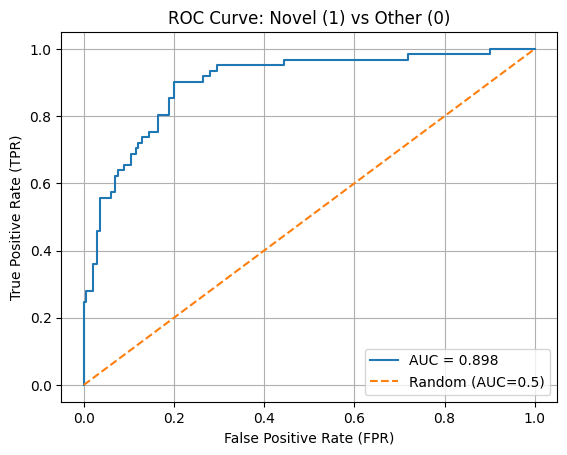

In [ ]:
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc(y_true, y_score):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC=0.5)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve: Novel (1) vs Other (0)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc(qy.cpu().numpy(), prob_novel)

# X ekseni (FPR): “Other (0) olanların kaçına yanlışlıkla Novel (1) dedik?” → yanlış alarm oranı
# Y ekseni (TPR): “Gerçek Novel (1) vakaların kaçını yakaladık?” → duyarlılık / recall

# Eğri turuncu rastgele çizginin (AUC=0.5) epey üstünde
# Bu, modelin rastgele tahminden çok daha iyi ayırdığını gösterir. Eğri ne kadar sol-üst köşeye yakınsa o kadar iyi.

In [59]:
@torch.no_grad()
def predict_one(test_index, protos, threshold=0.5):
    encoder.eval()

    x, y = test_ds[test_index]
    x = x.unsqueeze(0).to(DEVICE)           # [1, 3, H, W]
    emb = encoder(x)                        # [1, D]

    logits = emb @ protos.T                 # [1, 2] (0=other, 1=novel)
    prob_novel = torch.softmax(logits, dim=1)[0, 1].item()

    pred = 1 if prob_novel >= threshold else 0
    true_bin = 1 if test_y[test_index] == NOVEL_CLASS else 0

    return prob_novel, pred, true_bin

test_index = 1754  # Buraya test  setinden rastgele bir index yazın
prob, pred, true_bin = predict_one(test_index, protos)

print(f"idx={test_index} | true={true_bin} | prob_novel={prob:.3f} | pred={pred}  (1=novel, 0=other)")

idx=1754 | true=0 | prob_novel=0.662 | pred=1  (1=novel, 0=other)


In [56]:
test_ds[0][1]

array([5])

In [57]:
import random
print(random.sample(range(len(test_ds)), 10))


[869, 1630, 833, 1845, 1388, 598, 761, 1754, 1392, 1045]
